# Modellierung mit Prophet — PM2.5 Beijing

**Capstone-Projekt · CRISP-DM Phase 4 (Modeling)**  
Bettina Gertjerenken · Kai Steffen

Wir trainieren **Facebook Prophet** auf den Daten aus Kapitel 03 und vergleichen mehrere Konfigurationen:

1. **Basis, univariat** (nur `ds`+`y`) — Referenz,
2. **Basis + Wetter-Regressoren**,
3. **Behandelt + Regressoren**,
4. **Behandelt + Regressoren + Log-Ziel** (gegen die Rechtsschiefe),
5. **+ chinesische Feiertage** (`add_country_holidays`) — Zusatzlauf: hilft das?

Danach erweitern wir das Ganze auf **alle 12 Stationen**.

> ⚙️ **Kernel:** Umgebung **`ts-tutorial`** wählen (dort ist Prophet installiert).  
> 📁 **Voraussetzung:** Kapitel 03 einmal ausführen, damit `../data/prepared/basis/` und `../data/prepared/behandelt/` gefüllt sind.

## 1. Bibliotheken & Prophet-Version

Wir arbeiten mit der in `ts-tutorial` installierten Prophet-Version (**1.3.0**) und nutzen nur die stabile 
öffentliche API (`Prophet`, `add_regressor`, `fit`, `predict`, `plot_components`).

In [1]:
import warnings; warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import prophet

from prophet import Prophet



print("Prophet-Version:", prophet.__version__)   # sollte 1.3.0 sein



sns.set_theme(style="whitegrid")

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold"})

AMBER, RUST, SLATE, TEAL, MOSS = "#E0912F", "#C4471C", "#3A4148", "#1C7293", "#2C5F2D"

Prophet-Version: 1.3.0


## 2. Konfiguration

Zentrale Einstellungen an einem Ort. `REGRESSOREN` sind die in Kapitel 03 aufbereiteten Wetter- und Windrichtungs-Spalten.

In [2]:
STATION = "Aotizhongxin"          # Beispielstation fuer die Detail-Analyse

PREP = Path("../data/prepared")



REGRESSOREN = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]



# einheitliche Prophet-Grundeinstellung fuer alle Laeufe (fairer Vergleich)

PROPHET_KWARGS = dict(

    yearly_seasonality=True,

    weekly_seasonality=True,

    daily_seasonality=True,

    changepoint_prior_scale=0.05,

)

## 3. Hilfsfunktionen: Laden & Metriken

Neben **MAE** und **RMSE** geben wir auch **MAPE** (mittlerer prozentualer Fehler) aus. 
MAPE ist gut interpretierbar ("im Schnitt X %% daneben"), reagiert aber empfindlich auf sehr kleine Messwerte.

In [3]:
def lade(variante, station=STATION):

    """variante = 'basis' oder 'behandelt' -> (train, test)."""

    tr = pd.read_csv(PREP / variante / f"prophet_train_{station}.csv", parse_dates=["ds"])

    te = pd.read_csv(PREP / variante / f"prophet_test_{station}.csv",  parse_dates=["ds"])

    return tr, te



def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mape(y, yhat): return float(np.mean(np.abs((y - yhat) / y)) * 100)   # in %

## 4. Kernfunktion: trainieren & vorhersagen

**Eine** Funktion für alle Konfigurationen — so bleibt der Vergleich fair. Sie kann:

- beliebige **Regressoren** einbinden (`add_regressor`),
- optional auf dem **Log-Ziel** trainieren (`log=True`): intern `log1p(y)`, am Ende mit `expm1` zurücktransformiert.

So ist die Vorhersage immer in echten µg/m³ — dadurch sind MAE/RMSE über alle Konfigurationen direkt vergleichbar.

In [4]:
def fit_predict(train, test, regressoren=None, log=False, feiertage=None):

    regressoren = regressoren or []



    # Trainingsframe im Prophet-Format (ds, y[, Regressoren]) bauen

    tr = pd.DataFrame({"ds": train["ds"].values})

    tr["y"] = np.log1p(train["y"].values) if log else train["y"].values

    for r in regressoren:

        tr[r] = train[r].values



    m = Prophet(**PROPHET_KWARGS)

    if feiertage:

        m.add_country_holidays(country_name=feiertage)   # z.B. "CN" = China

    for r in regressoren:

        m.add_regressor(r)

    m.fit(tr)



    fut = test[["ds"] + regressoren].copy()      # Regressoren muessen im Test vorliegen

    fc = m.predict(fut)



    # ggf. zuruecktransformieren (log -> µg/m³)

    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)

    out = test[["ds", "y"]].merge(fc[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")

    for c in ["yhat", "yhat_lower", "yhat_upper"]:

        out[c] = rueck(out[c]).clip(lower=0)      # PM2.5 >= 0

    return m, fc, out

## 5. Schöne Plot-Funktionen

In [5]:
def plot_forecast(out, titel, farbe=TEAL, tage=1):

    g = out.set_index("ds").resample(f"{tage}D").mean()

    plt.figure(figsize=(12, 4))

    plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=farbe, alpha=0.18, label="Unsicherheit")

    plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")

    plt.plot(g.index, g["yhat"], color=farbe, lw=1.6, label="Prophet")

    plt.ylabel("PM2.5 (µg/m³)"); plt.title(titel); plt.legend(loc="upper right"); plt.tight_layout(); plt.show()



def plot_scatter(out, titel, farbe=TEAL):

    plt.figure(figsize=(4.6, 4.6))

    plt.scatter(out["y"], out["yhat"], s=4, alpha=0.2, color=farbe)

    lim = max(out["y"].max(), out["yhat"].max())

    plt.plot([0, lim], [0, lim], color=RUST, lw=1.2, ls="--", label="perfekt")

    plt.xlabel("echte PM2.5"); plt.ylabel("Vorhersage"); plt.title(titel); plt.legend()

    plt.tight_layout(); plt.show()

## 6. Detail-Analyse für eine Station: 4 Konfigurationen

Wir lassen für `STATION` alle vier Konfigurationen laufen und sammeln die Fehlermaße. 

Der fünfte Lauf schaltet zusätzlich **chinesische Feiertage** dazu (`m.add_country_holidays("CN")`). 
Hintergrund: Rund um das **Frühlingsfest** ändern sich Verkehr, Industrie und Feuerwerk stark — das kann PM2.5 sichtbar beeinflussen.

> ⏱️ **Laufzeit:**, die fünf Läufe zusammen ca. **6–15 Minuten**.

In [6]:
konfigs = {

    "Basis (univariat)":       dict(variante="basis",     regressoren=[],          log=False),

    "Basis + Regressoren":     dict(variante="basis",     regressoren=REGRESSOREN, log=False),

    "Behandelt + Regressoren": dict(variante="behandelt", regressoren=REGRESSOREN, log=False),

    "Behandelt + Reg + Log":   dict(variante="behandelt", regressoren=REGRESSOREN, log=True),

    "+ Feiertage (CN)":        dict(variante="behandelt", regressoren=REGRESSOREN, log=True, feiertage="CN"),

}



modelle, ergebnisse, zeilen = {}, {}, []

for name, cfg in konfigs.items():

    tr, te = lade(cfg["variante"])

    m, fc, out = fit_predict(tr, te, regressoren=cfg["regressoren"], log=cfg["log"],

                             feiertage=cfg.get("feiertage"))

    modelle[name], ergebnisse[name] = (m, fc), out

    zeilen.append({"Konfiguration": name, "MAE": mae(out["y"], out["yhat"]),

                   "RMSE": rmse(out["y"], out["yhat"]), "MAPE %": mape(out["y"], out["yhat"])})

    print(f"fertig: {name}")



metriken = pd.DataFrame(zeilen)

print(); print(metriken.to_string(index=False))

15:56:22 - cmdstanpy - INFO - Chain [1] start processing
15:56:29 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis (univariat)


15:56:34 - cmdstanpy - INFO - Chain [1] start processing
15:56:47 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis + Regressoren


15:56:51 - cmdstanpy - INFO - Chain [1] start processing
15:56:55 - cmdstanpy - INFO - Chain [1] done processing


fertig: Behandelt + Regressoren


15:57:00 - cmdstanpy - INFO - Chain [1] start processing
15:57:05 - cmdstanpy - INFO - Chain [1] done processing


fertig: Behandelt + Reg + Log


15:57:11 - cmdstanpy - INFO - Chain [1] start processing
15:57:22 - cmdstanpy - INFO - Chain [1] done processing


fertig: + Feiertage (CN)

          Konfiguration       MAE       RMSE     MAPE %
      Basis (univariat) 78.825579 114.018084  97.473757
    Basis + Regressoren 51.890059  77.653385  80.626056
Behandelt + Regressoren 39.661326  60.264448 106.365561
  Behandelt + Reg + Log 39.587539  66.515294  65.442420
       + Feiertage (CN) 39.879763  66.766373  67.940386


**Fehlermaße im Vergleich** (kleiner = besser):

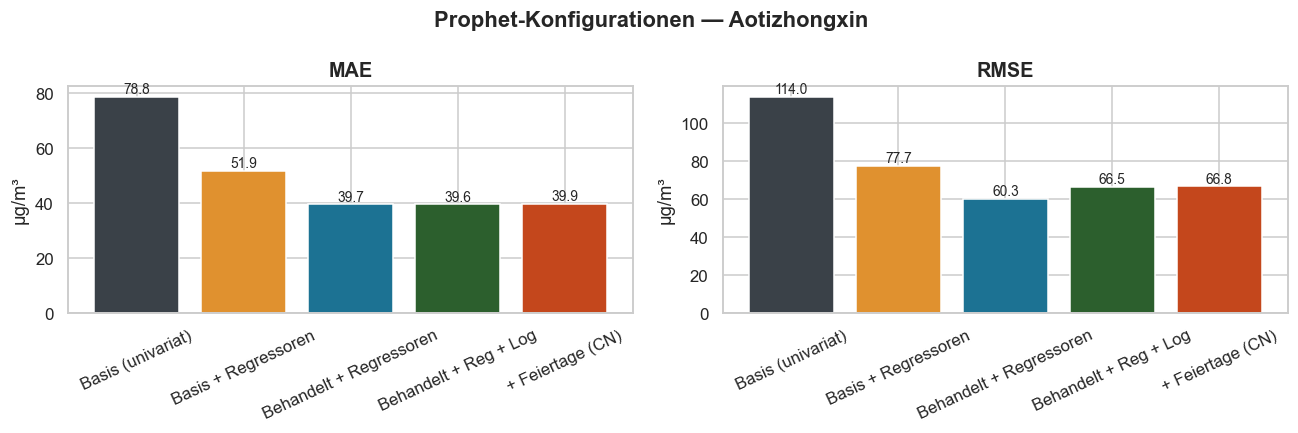

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

farben = [SLATE, AMBER, TEAL, MOSS, RUST]

for i, metrik in enumerate(["MAE", "RMSE"]):

    bars = ax[i].bar(metriken["Konfiguration"], metriken[metrik], color=farben)

    ax[i].set_title(metrik); ax[i].set_ylabel("µg/m³")

    ax[i].tick_params(axis="x", rotation=25)

    for b, v in zip(bars, metriken[metrik]):

        ax[i].text(b.get_x()+b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Prophet-Konfigurationen — {STATION}", fontweight="bold")

plt.tight_layout(); plt.show()

**Vorhersage vs. echte Werte** für die beste (meist letzte) Konfiguration:

Beste Konfiguration nach RMSE: Behandelt + Regressoren


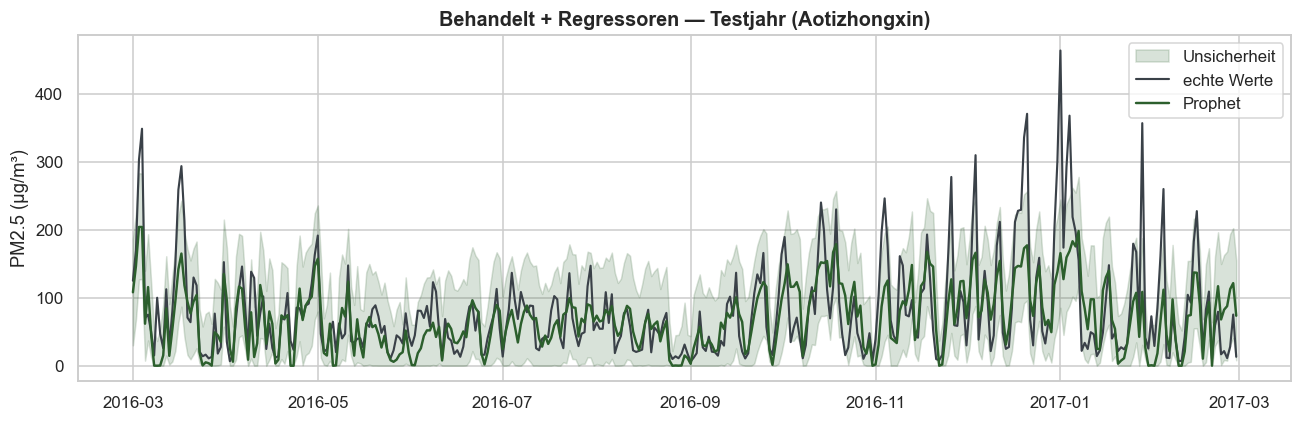

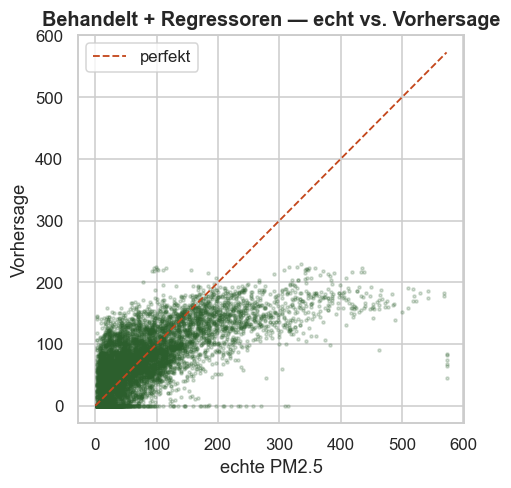

In [8]:
bestname = metriken.sort_values("RMSE").iloc[0]["Konfiguration"]

print("Beste Konfiguration nach RMSE:", bestname)

plot_forecast(ergebnisse[bestname], f"{bestname} — Testjahr ({STATION})", farbe=MOSS)

plot_scatter(ergebnisse[bestname], f"{bestname} — echt vs. Vorhersage", farbe=MOSS)

**Prophet-Komponenten** der besten Konfiguration (Trend, Jahres-, Wochen-, Tagesmuster).

> Hinweis: Wenn die beste Konfiguration das **Log-Ziel** nutzt, sind diese Komponenten auf der **log-Skala** dargestellt.

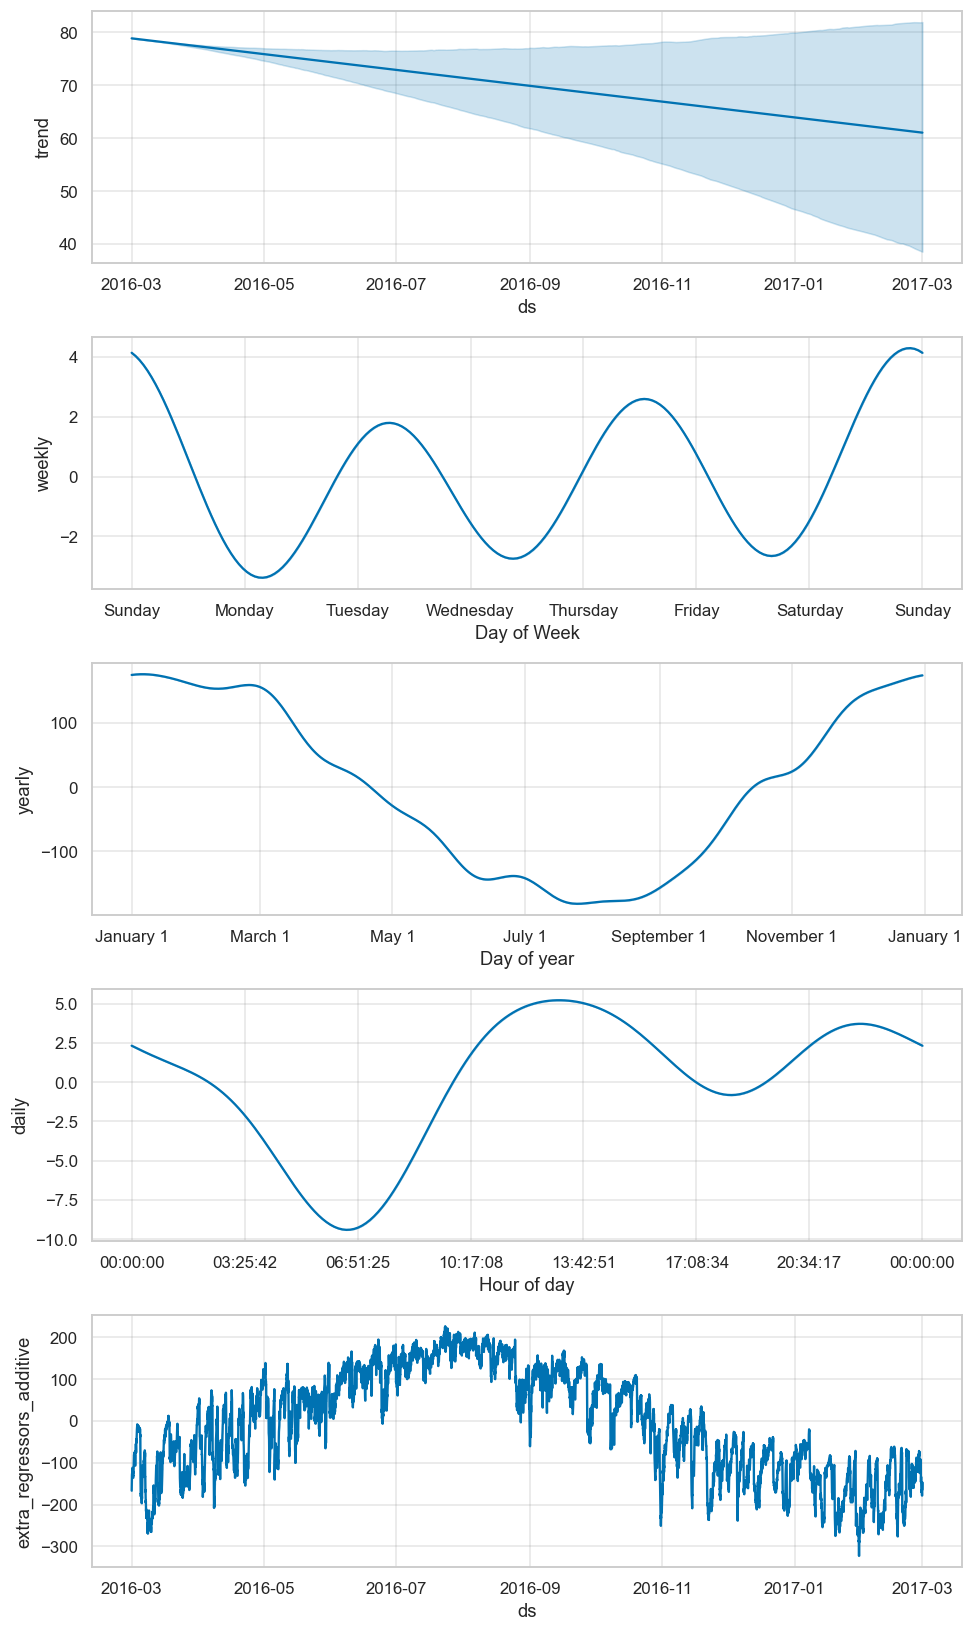

In [9]:
m_best, fc_best = modelle[bestname]

fig = m_best.plot_components(fc_best); plt.show()

## 7. Erweiterung auf alle 12 Stationen

Jetzt lassen wir ausgewählte Konfigurationen über **alle Stationen** laufen und mitteln die Fehlermaße. 
Zum Vergleich nehmen wir drei Stufen: **Referenz** (Basis univariat), **volle Ausbaustufe** (Behandelt + Reg + Log) und **+ chinesische Feiertage**.

> ⏱️ **Achtung Laufzeit:** 12 Stationen × 3 Konfigurationen ≈ **36 Fits** → grob **45–100 Minuten**. 
Zum Ausprobieren erst mit `SCHNELLTEST = True` (nur 2 Stationen) starten!

In [10]:
import time



SCHNELLTEST = True     # True = nur die ersten 2 Stationen (schnell testen); False = alle 12



sweep_konfigs = {

    "Basis (univariat)":     dict(variante="basis",     regressoren=[],          log=False),

    "Behandelt + Reg + Log": dict(variante="behandelt", regressoren=REGRESSOREN, log=True),

    "+ Feiertage (CN)":      dict(variante="behandelt", regressoren=REGRESSOREN, log=True, feiertage="CN"),

}



stationen = sorted(p.name.replace("prophet_train_", "").replace(".csv", "")

                   for p in (PREP / "basis").glob("prophet_train_*.csv"))

if SCHNELLTEST:

    stationen = stationen[:2]

print(f"{len(stationen)} Station(en): {stationen}")



resultate = []

for st in stationen:

    for name, cfg in sweep_konfigs.items():

        t0 = time.time()

        tr, te = lade(cfg["variante"], station=st)

        _, _, out = fit_predict(tr, te, regressoren=cfg["regressoren"], log=cfg["log"],

                                feiertage=cfg.get("feiertage"))

        resultate.append({"Station": st, "Konfiguration": name,

                          "MAE": mae(out["y"], out["yhat"]), "RMSE": rmse(out["y"], out["yhat"]),

                          "MAPE %": mape(out["y"], out["yhat"])})

        print(f"  {st:14s} | {name:22s} | {time.time()-t0:5.0f}s")



ergebnis_alle = pd.DataFrame(resultate)

ergebnis_alle.to_csv("../data/prophet_ergebnisse_stationen.csv", index=False)

print("\ngespeichert: ../data/prophet_ergebnisse_stationen.csv")

2 Station(en): ['Aotizhongxin', 'Changping']


15:57:26 - cmdstanpy - INFO - Chain [1] start processing
15:57:33 - cmdstanpy - INFO - Chain [1] done processing


  Aotizhongxin   | Basis (univariat)      |    10s


15:57:37 - cmdstanpy - INFO - Chain [1] start processing
15:57:42 - cmdstanpy - INFO - Chain [1] done processing


  Aotizhongxin   | Behandelt + Reg + Log  |     9s


...

  Changping      | Basis (univariat)      |    13s


15:58:15 - cmdstanpy - INFO - Chain [1] start processing
15:58:21 - cmdstanpy - INFO - Chain [1] done processing


  Changping      | Behandelt + Reg + Log  |    11s


15:58:27 - cmdstanpy - INFO - Chain [1] start processing
15:58:43 - cmdstanpy - INFO - Chain [1] done processing


  Changping      | + Feiertage (CN)       |    22s

gespeichert: ../data/prophet_ergebnisse_stationen.csv


**Fehlermaße je Station** (beide Konfigurationen nebeneinander):

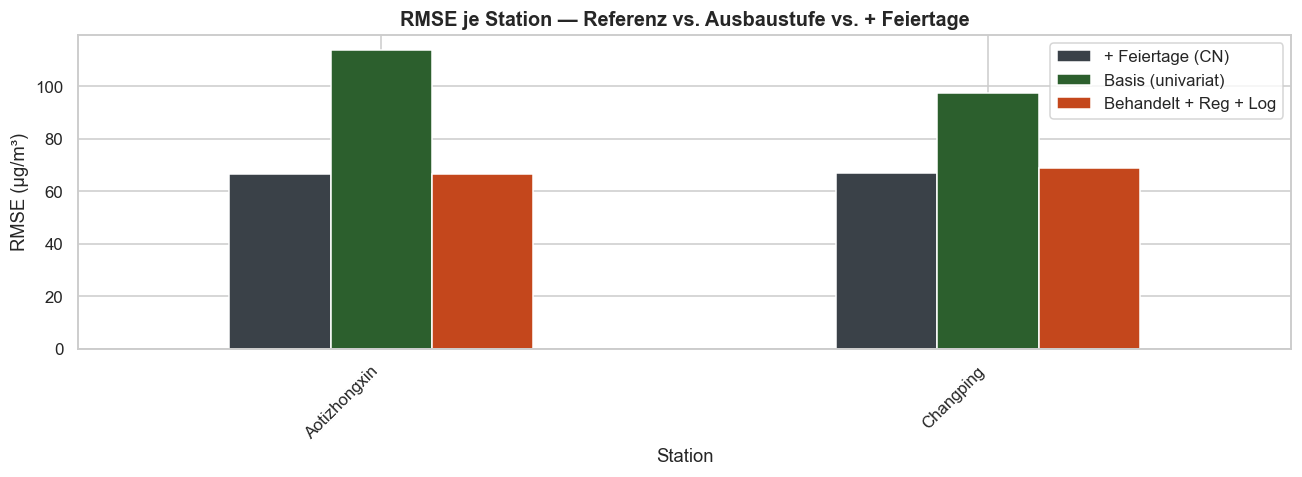

In [11]:
pivot = ergebnis_alle.pivot(index="Station", columns="Konfiguration", values="RMSE")

pivot.plot(kind="bar", figsize=(12, 4.5), color=[SLATE, MOSS, RUST])

plt.ylabel("RMSE (µg/m³)"); plt.title("RMSE je Station — Referenz vs. Ausbaustufe vs. + Feiertage")

plt.xticks(rotation=45, ha="right"); plt.legend(title=""); plt.tight_layout(); plt.show()

**Durchschnitt über alle gerechneten Stationen:**

In [12]:
zusammen = ergebnis_alle.groupby("Konfiguration")[["MAE", "RMSE", "MAPE %"]].mean().round(2)

print(zusammen.to_string())

                         MAE    RMSE  MAPE %
Konfiguration                               
+ Feiertage (CN)       39.73   66.82   62.84
Basis (univariat)      72.69  105.77   98.19
Behandelt + Reg + Log  40.40   67.75   61.54


## 8. Ergebnis & Ausblick

**Ergebnis:** Prophet ist mit **allen Regressoren** und optionalem **Log-Ziel** trainiert, für eine Station im Detail 
und über **alle 12 Stationen** ausgewertet. Die MAE/RMSE/MAPE-Vergleiche zeigen, welche Konfiguration am besten trägt.

**Nächste Schritte:**
- Ggf. `changepoint_prior_scale` / Saisonalitäten feinjustieren (Hyperparameter-Tuning).
- Dieselbe Test-Logik (gleicher Split, gleiche Metriken) für **Chronos** und **PatchTST** — dann sind alle drei Modelle fair vergleichbar.

Die Ergebnis-Tabelle liegt als `../data/prophet_ergebnisse_stationen.csv` bereit und kann direkt in den Modellvergleich einfließen.